<a href="https://colab.research.google.com/github/carles2710-sys/Predicci-n-precio-apto-Bogota/blob/main/Carles_Prediccion_precio_venta_10_05_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"https://colab.research.google.com/drive/10pSlz48wlF5E5k_7qW9rOpPMuvl5Nais?usp=sharing"

'https://colab.research.google.com/drive/10pSlz48wlF5E5k_7qW9rOpPMuvl5Nais?usp=sharing'

---

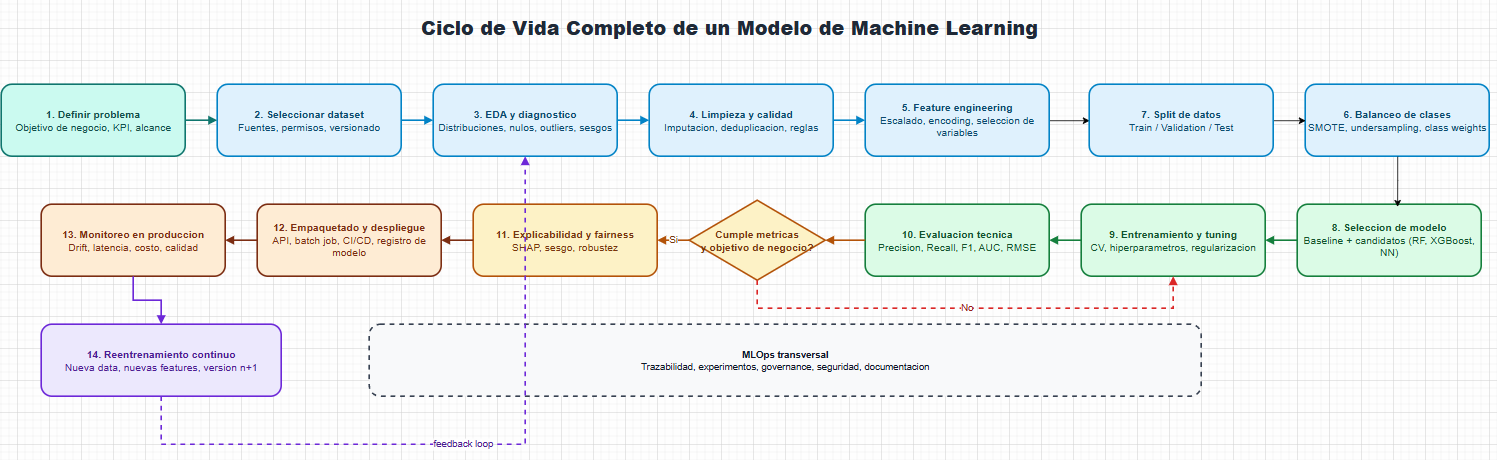

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
import gdown
import os

file_id = '1Ix5y51cjtcbipyzM75jx8CthSt3WEwOX'
output = '2023_bogota_apartments_processed.json'

if not os.path.exists(output):
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output, quiet=False)

try:
    df_apartments = pd.read_json(output)
    print("Dataset loaded successfully!")
    display(df_apartments.head(100))
except Exception as e:
    print(f"An error occurred while reading the JSON: {e}")

Downloading...
From (original): https://drive.google.com/uc?id=1Ix5y51cjtcbipyzM75jx8CthSt3WEwOX
From (redirected): https://drive.google.com/uc?id=1Ix5y51cjtcbipyzM75jx8CthSt3WEwOX&confirm=t&uuid=7ca60498-3429-4a20-94be-7de9414ceefa
To: /content/2023_bogota_apartments_processed.json
100%|██████████| 158M/158M [00:01<00:00, 144MB/s]


Dataset loaded successfully!


,_id,codigo,tipo_propiedad,tipo_operacion,precio_venta,precio_arriendo,area,habitaciones,banos,administracion,...,permite_mascotas,gimnasio,ascensor,conjunto_cerrado,coords_modified,localidad,barrio,estacion_tm_cercana,distancia_estacion_tm_m,is_cerca_estacion_tm
0,{'$oid': '653fb51aaca1614a5b672d7d'},374-M2718950,APARTAMENTO,VENTA Y ARRIENDO,{'$numberLong': '2500000000'},13500000,320,4,5,2500000,...,1,1,1,1,False,USAQUEN,CIUDADELA REAL,Alcalá,2798.28,0
1,{'$oid': '653fb51aaca1614a5b672d7e'},2510-M4156145,APARTAMENTO,VENTA,485000000,{'$numberDouble': 'NaN'},84,3,3,680000,...,0,0,1,1,False,USAQUEN,SAN PATRICIO,Pepe Sierra,1116.77,0
2,{'$oid': '653fb51aaca1614a5b672d7f'},10312-M2873283,APARTAMENTO,VENTA Y ARRIENDO,1980000000,9000000,248,3,3,2200000,...,1,0,1,1,False,USAQUEN,CERROS DE SANTA BARBARA,Pepe Sierra,3140.36,0
3,{'$oid': '653fb51aaca1614a5b672d80'},10139-M4343016,APARTAMENTO,VENTA,485000000,{'$numberDouble': 'NaN'},77.2,3,2,367000,...,1,1,1,1,False,SUBA,CAMPOS DE SILENCIO,Calle 161,933.85,0
4,{'$oid': '653fb51aaca1614a5b672d81'},10139-M3692828,APARTAMENTO,VENTA,1570000000,{'$numberDouble': 'NaN'},213,3,4,994000,...,0,1,1,1,False,USAQUEN,GINEBRA,Prado,2769.19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,{'$oid': '653fb529aca1614a5b672ddc'},4186-M3958286,APARTAMENTO,VENTA,1400000000,{'$numberDouble': 'NaN'},163,2,3,1293600,...,0,0,0,1,False,CHAPINERO,S.C. EL CHICO,Virrey,535.17,0
96,{'$oid': '653fb529aca1614a5b672ddd'},3774-M3860740,APARTAMENTO,VENTA,1250000000,{'$numberDouble': 'NaN'},143,3,4,809000,...,0,1,1,0,False,CHAPINERO,S.C. EL CHICO,Virrey,295.24,1
97,{'$oid': '653fb529aca1614a5b672dde'},2592-M3535233,APARTAMENTO,VENTA,670000000,{'$numberDouble': 'NaN'},82,3,2,480000,...,0,0,1,1,False,USAQUEN,SANTA BARBARA CENTRAL I SECTOR,Calle 127,1599.96,0
98,{'$oid': '653fb529aca1614a5b672ddf'},3074-M3656922,APARTAMENTO,VENTA,850000000,{'$numberDouble': 'NaN'},172,3,3,1392000,...,0,0,1,0,False,SUBA,PUENTE LARGO SECTOR I Y II,Puentelargo,464.82,1


### Limpieza y Conversión de la Columna `precio_venta`

The `precio_venta` column currently has an `object` data type and contains entries that are JSON-like strings (e.g., `{$numberLong: '2500000000'}`). We need to extract the numerical value from these strings and convert the entire column to a proper numeric type. Non-convertible values will be set to `NaN`.

### 1. Definir el problema

| Elemento | Detalle |
|---|---|
| **Objetivo de Negocio** | Predecir el precio de venta de una casa |
| **Tipo de problema** | Regresión supervisada |

referencia_dataset = https://github.com/builker-col/bogota-apartments/tree/master/data/processed

## 3. Análisis Exploratorio de Datos (EDA)

In [ ]:
df_apartments.describe()

,longitud,latitud,distancia_estacion_tm_m,is_cerca_estacion_tm
count,85310.000000,85310.000000,85310.000000,85310.000000
mean,-74.064865,4.686379,1251.216538,0.213211
std,0.035344,0.039746,836.411013,0.409578
min,-74.215130,4.467270,1.530000,0.000000
25%,-74.071420,4.661080,564.660000,0.000000
50%,-74.052986,4.690756,1143.310000,0.000000
75%,-74.043690,4.715771,1703.822500,0.000000
max,-74.013000,4.821250,7206.140000,1.000000


In [ ]:
# numero de columnas
print(f"numero de columnas: {df_apartments.shape[1]}")
# numero de filas
print(f"numero de filas: {df_apartments.shape[0]}")

numero de columnas: 41
numero de filas: 85310


In [ ]:
df_apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85310 entries, 0 to 85309
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   _id                                  85310 non-null  object 
 1   codigo                               85310 non-null  object 
 2   tipo_propiedad                       85310 non-null  object 
 3   tipo_operacion                       85310 non-null  object 
 4   precio_venta                         85310 non-null  object 
 5   precio_arriendo                      85310 non-null  object 
 6   area                                 85310 non-null  object 
 7   habitaciones                         85310 non-null  object 
 8   banos                                85310 non-null  object 
 9   administracion                       85310 non-null  object 
 10  parqueaderos                         85310 non-null  object 
 11  sector                      

## 4. Limpieza y Calidad de Datos

In [ ]:
import re
import pandas as pd

def extract_number_long_or_convert(value):
    # 1. Handle case where the value is already a dictionary
    if isinstance(value, dict):
        # Check for both $numberLong and $numberDouble
        for key in ['$numberLong', '$numberDouble']:
            if key in value:
                return value[key]
        return None

    if not isinstance(value, str):
        return value

    # 2. Case: {'$numberLong': '2500000000'} or similar string formats
    match_number = re.search(r'\$number(?:Long|Double)\s*["\']?\s*:\s*["\']?([\d.]+)', value)
    if match_number:
        return match_number.group(1)

    # 3. Case: General 'key: number' or ': number' pattern
    match_colon_number = re.search(r':\s*["\']?([\d.]+)', value)
    if match_colon_number:
        return match_colon_number.group(1)

    # 4. Direct numeric string conversion
    try:
        return float(value)
    except (ValueError, TypeError):
        return value

# Columns to clean
cols_to_clean = ['precio_venta', 'precio_arriendo', 'administracion', 'precio_arriendo_anterior']

for col in cols_to_clean:
    new_col_name = f"{col}_cleaned"
    # Apply extraction
    df_apartments[new_col_name] = df_apartments[col].apply(extract_number_long_or_convert)
    # Convert to numeric
    df_apartments[new_col_name] = pd.to_numeric(df_apartments[new_col_name], errors='coerce')
    print(f"Processed {col} -> {new_col_name}. Nulls: {df_apartments[new_col_name].isnull().sum()}")

# Display results
display(df_apartments[[c for c in df_apartments.columns if '_cleaned' in c]].head(10))

Processed precio_venta -> precio_venta_cleaned. Nulls: 28230
Processed precio_arriendo -> precio_arriendo_cleaned. Nulls: 56101
Processed administracion -> administracion_cleaned. Nulls: 16230
Processed precio_arriendo_anterior -> precio_arriendo_anterior_cleaned. Nulls: 81862


,precio_venta_cleaned,precio_arriendo_cleaned,administracion_cleaned,precio_arriendo_anterior_cleaned
0,2.500000e+09,13500000.0,2500000.0,NaN
1,4.850000e+08,NaN,680000.0,NaN
2,1.980000e+09,9000000.0,2200000.0,NaN
3,4.850000e+08,NaN,367000.0,NaN
4,1.570000e+09,NaN,994000.0,NaN
5,7.500000e+08,NaN,400000.0,NaN
6,3.670000e+09,NaN,3000000.0,NaN
7,4.423000e+09,14000000.0,2600000.0,NaN
8,6.900000e+08,NaN,522000.0,NaN
9,5.400000e+08,NaN,300000.0,NaN


### Limpieza de Características Físicas

Vamos a convertir las columnas `area`, `habitaciones`, `banos` y `parqueaderos` a formato numérico. Esto nos permitirá realizar cálculos estadísticos y entrenar modelos.

In [ ]:
physical_cols = ['area', 'habitaciones', 'banos', 'parqueaderos','longitud', 'latitud', 'distancia_estacion_tm_m', 'piso']

for col in physical_cols:
    new_col_name = f"{col}_cleaned"
    # Reutilizamos la función de extracción robusta definida anteriormente
    df_apartments[new_col_name] = df_apartments[col].apply(extract_number_long_or_convert)
    df_apartments[new_col_name] = pd.to_numeric(df_apartments[new_col_name], errors='coerce')
    print(f"Procesada {col} -> {new_col_name}. Nulos: {df_apartments[new_col_name].isnull().sum()}")

# Mostrar resumen de las nuevas columnas físicas
display(df_apartments[[f"{c}_cleaned" for c in physical_cols]].describe())

Procesada area -> area_cleaned. Nulos: 2
Procesada habitaciones -> habitaciones_cleaned. Nulos: 9
Procesada banos -> banos_cleaned. Nulos: 7
Procesada parqueaderos -> parqueaderos_cleaned. Nulos: 9
Procesada longitud -> longitud_cleaned. Nulos: 0
Procesada latitud -> latitud_cleaned. Nulos: 0
Procesada distancia_estacion_tm_m -> distancia_estacion_tm_m_cleaned. Nulos: 0
Procesada piso -> piso_cleaned. Nulos: 38501


,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,longitud_cleaned,latitud_cleaned,distancia_estacion_tm_m_cleaned,piso_cleaned
count,85308.000000,85301.000000,85303.000000,85301.000000,85310.000000,85310.000000,85310.000000,46809.000000
mean,129.814277,2.556981,2.557706,1.528153,-74.064865,4.686379,1251.216538,9.187229
std,817.893878,0.854944,1.150804,1.043473,0.035344,0.039746,836.411013,49.553289
min,0.000000,1.000000,-3.000000,-2.000000,-74.215130,4.467270,1.530000,0.000000
25%,60.000000,2.000000,2.000000,1.000000,-74.071420,4.661080,564.660000,2.000000
50%,90.000000,3.000000,2.000000,1.000000,-74.052986,4.690756,1143.310000,4.000000
75%,152.000000,3.000000,3.000000,2.000000,-74.043690,4.715771,1703.822500,6.000000
max,142000.000000,8.000000,5.000000,4.000000,-74.013000,4.821250,7206.140000,2013.000000


### Verificación de valores nulos (NaN)

Por ahora, los valores no convertibles se mantienen como `NaN`. Aquí puedes ver un resumen de cuántas filas tienen al menos un valor nulo en las columnas procesadas.

In [ ]:
# Columnas que hemos limpiado hasta ahora
cleaned_cols = [c for c in df_apartments.columns if '_cleaned' in c]

# Ver cuántos nulos hay por columna
print("Valores nulos por columna limpia:")
print(df_apartments[cleaned_cols].isnull().sum())

# Ejemplo de filas que contienen algún nulo en las columnas físicas
filas_con_nulos = df_apartments[df_apartments[cleaned_cols].isnull().any(axis=1)]
print(f"\nTotal de filas con al menos un valor nulo: {len(filas_con_nulos)}")
display(filas_con_nulos[cleaned_cols].head())

# NOTA: Si quisieras eliminar estas filas permanentemente, usarías:
# df_apartments.dropna(subset=['precio_venta_cleaned'], inplace=True)

Valores nulos por columna limpia:
precio_venta_cleaned                28230
precio_arriendo_cleaned             56101
administracion_cleaned              16230
precio_arriendo_anterior_cleaned    81862
area_cleaned                            2
habitaciones_cleaned                    9
banos_cleaned                           7
parqueaderos_cleaned                    9
longitud_cleaned                        0
latitud_cleaned                         0
distancia_estacion_tm_m_cleaned         0
piso_cleaned                        38501
dtype: int64

Total de filas con al menos un valor nulo: 85276


,precio_venta_cleaned,precio_arriendo_cleaned,administracion_cleaned,precio_arriendo_anterior_cleaned,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,longitud_cleaned,latitud_cleaned,distancia_estacion_tm_m_cleaned,piso_cleaned
0,2.500000e+09,13500000.0,2500000.0,NaN,320.0,4.0,5.0,3.0,-74.026855,4.715475,2798.28,8.0
1,4.850000e+08,NaN,680000.0,NaN,84.0,3.0,3.0,1.0,-74.045900,4.694500,1116.77,2.0
2,1.980000e+09,9000000.0,2200000.0,NaN,248.0,3.0,3.0,3.0,-74.027916,4.690854,3140.36,3.0
3,4.850000e+08,NaN,367000.0,NaN,77.2,3.0,2.0,1.0,-74.056400,4.742382,933.85,2.0
4,1.570000e+09,NaN,994000.0,NaN,213.0,3.0,4.0,3.0,-74.028244,4.708852,2769.19,4.0


### 4.2. Limpieza de Anomalías (Valores Negativos y Ceros)

En el paso anterior notamos valores imposibles (ej. baños negativos). Vamos a ajustar estos valores a `NaN` para que no distorsionen el análisis.

In [ ]:
# Corregir valores menores o iguales a cero en columnas donde no tiene sentido
# Área debe ser > 0. Habitaciones, baños y parqueaderos deben ser >= 0.

df_apartments.loc[df_apartments['area_cleaned'] <= 0, 'area_cleaned'] = None

for col in ['habitaciones_cleaned', 'banos_cleaned', 'parqueaderos_cleaned']:
    mask_negativo = df_apartments[col] < 0
    if mask_negativo.any():
        print(f"Corrigiendo {mask_negativo.sum()} valores negativos en {col}")
        df_apartments.loc[mask_negativo, col] = None

# Ver resumen final de calidad
print("\nResumen estadístico tras limpiar anomalías:")
display(df_apartments[[c for c in df_apartments.columns if '_cleaned' in c]].describe())

Corrigiendo 1 valores negativos en banos_cleaned
Corrigiendo 1 valores negativos en parqueaderos_cleaned

Resumen estadístico tras limpiar anomalías:


,precio_venta_cleaned,precio_arriendo_cleaned,administracion_cleaned,precio_arriendo_anterior_cleaned,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,longitud_cleaned,latitud_cleaned,distancia_estacion_tm_m_cleaned,piso_cleaned
count,5.708000e+04,2.920900e+04,6.908000e+04,3.448000e+03,85180.000000,85301.000000,85302.000000,85300.000000,85310.000000,85310.000000,85310.000000,46809.000000
mean,1.506167e+09,1.322773e+07,3.293832e+06,1.851860e+07,130.009348,2.556981,2.557771,1.528195,-74.064865,4.686379,1251.216538,9.187229
std,3.861128e+10,2.853653e+08,5.924717e+07,4.345516e+08,818.492686,0.854944,1.150653,1.043409,0.035344,0.039746,836.411013,49.553289
min,1.150000e+05,1.000000e+05,1.000000e+00,1.000000e+05,1.000000,1.000000,0.000000,0.000000,-74.215130,4.467270,1.530000,0.000000
25%,3.580000e+08,1.500000e+06,2.813000e+05,1.549200e+06,60.000000,2.000000,2.000000,1.000000,-74.071420,4.661080,564.660000,2.000000
50%,5.800000e+08,2.650000e+06,5.160000e+05,2.718000e+06,90.000000,3.000000,2.000000,1.000000,-74.052986,4.690756,1143.310000,4.000000
75%,1.100000e+09,5.400000e+06,9.746625e+05,5.100000e+06,152.000000,3.000000,3.000000,2.000000,-74.043690,4.715771,1703.822500,6.000000
max,4.250000e+12,2.550000e+10,3.800000e+09,2.000000e+10,142000.000000,8.000000,5.000000,4.000000,-74.013000,4.821250,7206.140000,2013.000000


In [ ]:
df_apartments.drop(columns=['_id','codigo','precio_venta', 'precio_arriendo', 'administracion', 'precio_arriendo_anterior','precio_arriendo_anterior_cleaned','descripcion','datetime','last_view','website','direccion'], inplace=True)

$0

In [ ]:
df_apartments.columns

Index(['tipo_propiedad', 'tipo_operacion', 'area', 'habitaciones', 'banos',
       'parqueaderos', 'sector', 'estrato', 'antiguedad', 'estado', 'longitud',
       'latitud', 'compañia', 'fecha_actualizacion_precio_venta',
       'precio_venta_anterior', 'fecha_actualizacion_precio_arriendo',
       'jacuzzi', 'piso', 'closets', 'chimenea', 'permite_mascotas',
       'gimnasio', 'ascensor', 'conjunto_cerrado', 'coords_modified',
       'localidad', 'barrio', 'estacion_tm_cercana', 'distancia_estacion_tm_m',
       'is_cerca_estacion_tm', 'precio_venta_cleaned',
       'precio_arriendo_cleaned', 'administracion_cleaned', 'area_cleaned',
       'habitaciones_cleaned', 'banos_cleaned', 'parqueaderos_cleaned',
       'longitud_cleaned', 'latitud_cleaned',
       'distancia_estacion_tm_m_cleaned', 'piso_cleaned'],
      dtype='object')

---

### Guardar copia de datos limpios

In [ ]:
# guardar en formato csv
df_apartments.to_csv('2023_bogota_apartments_cleaned.csv', index=False)

-----
### Lectura dataset limpio

In [ ]:
import pandas as pd
import gdown
import os

file_id = '1QSyaXlMyvLXl87B5CxQXHHYeFTvUEYLN'
output = "2023_bogota_apartments_cleaned.csv"

if not os.path.exists(output):
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, output, quiet=False)

try:
    df_cleaned_apartaments = pd.read_csv(output)
    print("Dataset loaded successfully!")
    display(df_cleaned_apartaments.head(100))
except Exception as e:
    print(f"An error occurred while reading the JSON: {e}")


Dataset loaded successfully!


/tmp/ipykernel_2844/2494352817.py:13: DtypeWarning: Columns (2,3,4,5,7,16,19,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cleaned_apartaments = pd.read_csv(output)


,tipo_propiedad,tipo_operacion,area,habitaciones,banos,parqueaderos,sector,estrato,antiguedad,estado,...,precio_arriendo_cleaned,administracion_cleaned,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,longitud_cleaned,latitud_cleaned,distancia_estacion_tm_m_cleaned,piso_cleaned
0,APARTAMENTO,VENTA Y ARRIENDO,320,4,5,3,COUNTRY,6,MAS DE 20 ANOS,USADO,...,13500000.0,2500000.0,320.0,4.0,5.0,3.0,-74.026855,4.715475,2798.28,8.0
1,APARTAMENTO,VENTA,84,3,3,1,SANTA BARBARA,6,MAS DE 20 ANOS,USADO,...,NaN,680000.0,84.0,3.0,3.0,1.0,-74.045900,4.694500,1116.77,2.0
2,APARTAMENTO,VENTA Y ARRIENDO,248,3,3,3,SANTA BARBARA,6,MAS DE 20 ANOS,USADO,...,9000000.0,2200000.0,248.0,3.0,3.0,3.0,-74.027916,4.690854,3140.36,3.0
3,APARTAMENTO,VENTA,77.2,3,2,1,COLINA Y ALREDEDORES,4,ENTRE 5 Y 10 ANOS,USADO,...,NaN,367000.0,77.2,3.0,2.0,1.0,-74.056400,4.742382,933.85,2.0
4,APARTAMENTO,VENTA,213,3,4,3,COUNTRY,3,ENTRE 5 Y 10 ANOS,USADO,...,NaN,994000.0,213.0,3.0,4.0,3.0,-74.028244,4.708852,2769.19,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,APARTAMENTO,VENTA,163,2,3,2,CHICO,6,ENTRE 10 Y 20 ANOS,USADO,...,NaN,1293600.0,163.0,2.0,3.0,2.0,-74.054184,4.676063,535.17,4.0
96,APARTAMENTO,VENTA,143,3,4,2,CHICO,6,ENTRE 10 Y 20 ANOS,USADO,...,NaN,809000.0,143.0,3.0,4.0,2.0,-74.056410,4.675427,295.24,3.0
97,APARTAMENTO,VENTA,82,3,2,2,SANTA BARBARA,6,ENTRE 0 Y 5 ANOS,USADO,...,NaN,480000.0,82.0,3.0,2.0,2.0,-74.040840,4.699258,1599.96,2.0
98,APARTAMENTO,VENTA,172,3,3,2,NIZA ALHAMBRA,5,MAS DE 20 ANOS,USADO,...,NaN,1392000.0,172.0,3.0,3.0,2.0,-74.064240,4.696310,464.82,2.0


### 5. Preparación de Muestra y Categorización

En esta sección:
1. Filtraremos el dataset para asegurar que el target (`precio_venta_cleaned`) sea válido.
2. Tomaremos una muestra representativa.
3. Categorizaremos variables como `tipo_operacion` y `tipo_propiedad` para que el modelo pueda interpretarlas.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Filtrar filas donde el target es nulo (no podemos predecir si no hay dato real)
df_target = df_cleaned_apartaments.dropna(subset=['precio_venta_cleaned']).copy()

# 2. Tomar una muestra (ej: 10,000 registros para agilizar)
df_sample = df_target.sample(n=min(10000, len(df_target)), random_state=42).copy()

# 3. Categorización de variables
# Limpiamos strings de tipo_operacion (quitar espacios y poner en mayúsculas)
for col in ['tipo_operacion', 'tipo_propiedad', 'sector']:
    df_sample[col] = df_sample[col].astype(str).str.strip().str.upper()

# Aplicar Label Encoding para convertir texto a números
le = LabelEncoder()
categorical_cols = ['tipo_operacion', 'tipo_propiedad', 'sector', 'localidad']

for col in categorical_cols:
    if col in df_sample.columns:
        df_sample[f'{col}_encoded'] = le.fit_transform(df_sample[col])
        print(f"Categorizada: {col} -> {col}_encoded")

# 4. Seleccionar columnas finales para el modelo
features = ['area_cleaned', 'habitaciones_cleaned', 'banos_cleaned', 'parqueaderos_cleaned',
            'estrato', 'tipo_operacion_encoded', 'tipo_propiedad_encoded', 'localidad_encoded']

# Limpiar estratos (convertir a numérico si es posible)
df_sample['estrato'] = pd.to_numeric(df_sample['estrato'], errors='coerce').fillna(0)

print(f"\nNuevo tamaño de la muestra: {df_sample.shape}")
display(df_sample[features + ['precio_venta_cleaned']].head())

Categorizada: tipo_operacion -> tipo_operacion_encoded
Categorizada: tipo_propiedad -> tipo_propiedad_encoded
Categorizada: sector -> sector_encoded
Categorizada: localidad -> localidad_encoded

Nuevo tamaño de la muestra: (10000, 45)


,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,estrato,tipo_operacion_encoded,tipo_propiedad_encoded,localidad_encoded,precio_venta_cleaned
38040,108.57,3.0,3.0,2.0,6.0,1,0,14,8.800000e+08
54784,72.00,2.0,2.0,1.0,5.0,1,0,4,5.500000e+08
63362,45.12,2.0,1.0,0.0,3.0,1,0,6,1.400000e+08
59130,109.00,3.0,3.0,2.0,5.0,1,0,17,4.950000e+08
63403,220.00,3.0,1.0,2.0,6.0,1,0,4,2.150000e+09


### 5.1 Categorización del Dataset Completo

In [ ]:
len(df_full_prepared), len(df_apartments)

(57080, 85310)

### 6. Análisis de Correlación

Visualizaremos cómo se relacionan las variables numéricas y categorizadas con nuestro objetivo: el precio de venta.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Trabajamos sobre el set completo que tiene target válido
df_full_prepared = df_cleaned_apartaments.dropna(subset=['precio_venta_cleaned']).copy()

# 2. Normalización de textos para evitar duplicados por formato
categorical_cols = ['tipo_operacion', 'tipo_propiedad', 'sector', 'localidad']
for col in categorical_cols:
    df_full_prepared[col] = df_full_prepared[col].astype(str).str.strip().str.upper()

# 3. Aplicar Label Encoding al dataset completo
le = LabelEncoder()
for col in categorical_cols:
    if col in df_full_prepared.columns:
        df_full_prepared[f'{col}_encoded'] = le.fit_transform(df_full_prepared[col])

# 4. Asegurar que el estrato sea numérico
df_full_prepared['estrato'] = pd.to_numeric(df_full_prepared['estrato'], errors='coerce').fillna(0)

# Definir columnas de interés para análisis/modelo
features_final = ['area_cleaned', 'habitaciones_cleaned', 'banos_cleaned', 'parqueaderos_cleaned',
                  'estrato', 'tipo_operacion_encoded', 'tipo_propiedad_encoded',
                  'sector_encoded', 'localidad_encoded']

print(f"Total de registros procesados: {len(df_full_prepared)}")
display(df_full_prepared[features_final + ['precio_venta_cleaned']].head())

Total de registros procesados: 57080


,area_cleaned,habitaciones_cleaned,banos_cleaned,parqueaderos_cleaned,estrato,tipo_operacion_encoded,tipo_propiedad_encoded,sector_encoded,localidad_encoded,precio_venta_cleaned
0,320.0,4.0,5.0,3.0,6.0,2,0,37,17,2.500000e+09
1,84.0,3.0,3.0,1.0,6.0,1,0,90,17,4.850000e+08
2,248.0,3.0,3.0,3.0,6.0,2,0,90,17,1.980000e+09
3,77.2,3.0,2.0,1.0,4.0,1,0,34,14,4.850000e+08
4,213.0,3.0,4.0,3.0,3.0,1,0,37,17,1.570000e+09


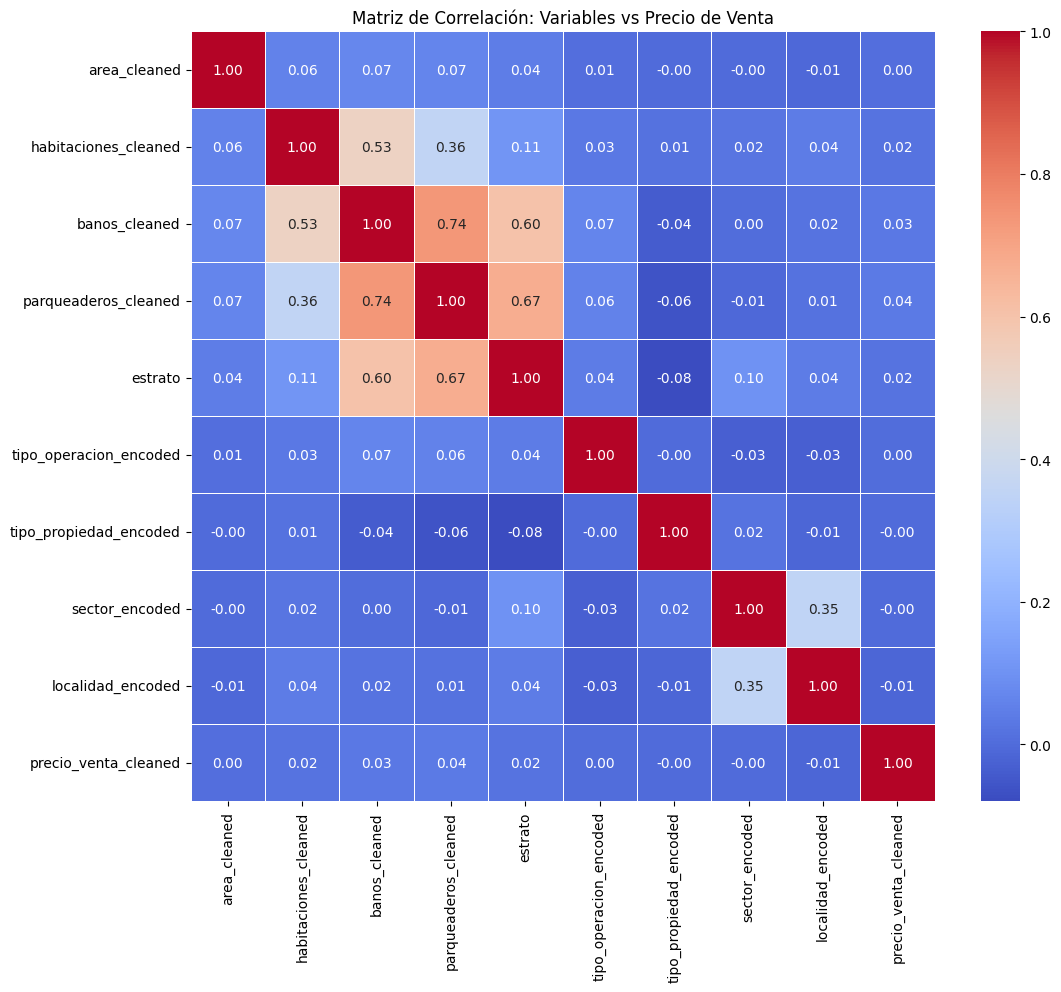

Correlación directa con el precio de venta:
precio_venta_cleaned      1.000000
parqueaderos_cleaned      0.036658
banos_cleaned             0.030624
estrato                   0.019571
habitaciones_cleaned      0.017502
area_cleaned              0.004181
tipo_operacion_encoded    0.002074
tipo_propiedad_encoded   -0.001573
sector_encoded           -0.003028
localidad_encoded        -0.013308
Name: precio_venta_cleaned, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas numéricas y las codificadas para el análisis
columns_for_corr = features_final + ['precio_venta_cleaned']
corr_matrix = df_full_prepared[columns_for_corr].corr()

# Configurar el gráfico
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación: Variables vs Precio de Venta')
plt.show()

# Mostrar específicamente la correlación con el target ordenada
print("Correlación directa con el precio de venta:")
print(corr_matrix['precio_venta_cleaned'].sort_values(ascending=False))

### 6.1 Refinando el Análisis (Filtrado de Outliers)

Para obtener correlaciones significativas, limitaremos el dataset a valores realistas de mercado.

### 7. División del Dataset (Train/Test Split)

Prepararemos las matrices de características (X) y el vector objetivo (y) usando las variables más relevantes detectadas.

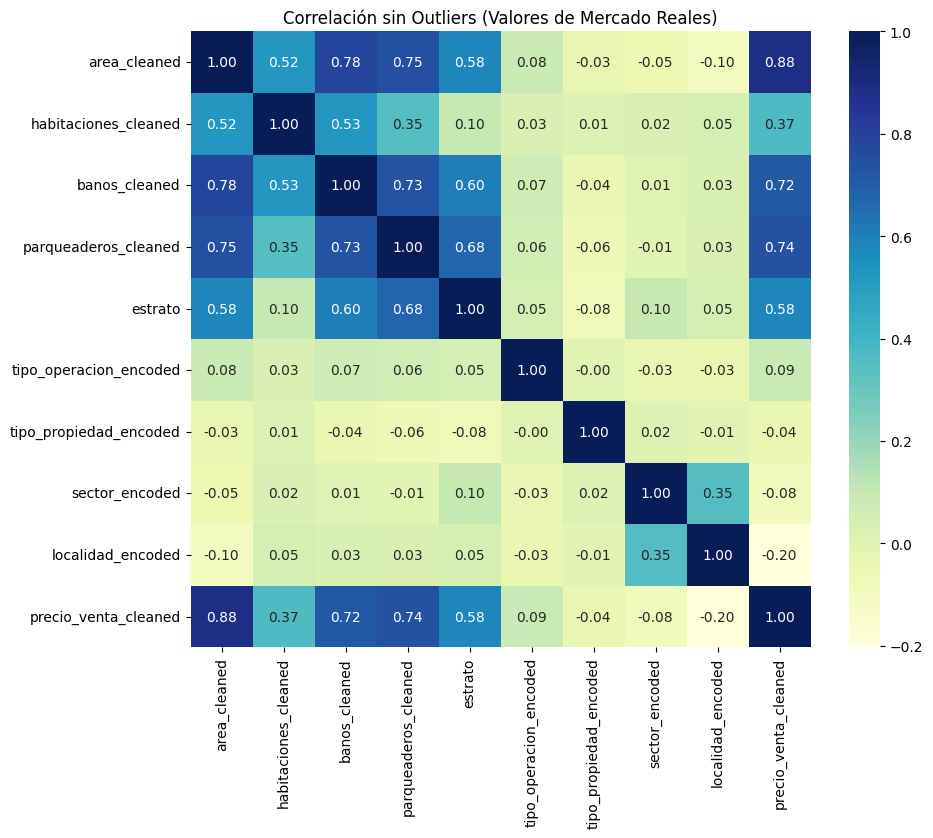

Features con mayor impacto detectado:
precio_venta_cleaned      1.000000
area_cleaned              0.884113
parqueaderos_cleaned      0.739465
banos_cleaned             0.715383
estrato                   0.580479
habitaciones_cleaned      0.368803
localidad_encoded         0.203086
tipo_operacion_encoded    0.091432
sector_encoded            0.084375
tipo_propiedad_encoded    0.038570
Name: precio_venta_cleaned, dtype: float64


In [ ]:
# Definir límites lógicos para limpiar el ruido estadístico
price_upper_limit = 5_000_000_000 # 5 mil millones
price_lower_limit = 50_000_000    # 50 millones
area_upper_limit = 800            # 800 m2

df_filtered = df_full_prepared[
    (df_full_prepared['precio_venta_cleaned'] >= price_lower_limit) &
    (df_full_prepared['precio_venta_cleaned'] <= price_upper_limit) &
    (df_full_prepared['area_cleaned'] > 10) &
    (df_full_prepared['area_cleaned'] <= area_upper_limit)
].copy()

# Recalcular correlación
corr_filtered = df_filtered[features_final + ['precio_venta_cleaned']].corr()

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlación sin Outliers (Valores de Mercado Reales)')
plt.show()

print("Features con mayor impacto detectado:")
print(corr_filtered['precio_venta_cleaned'].abs().sort_values(ascending=False))

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 1. Definimos características (X) y objetivo (y)
X = df_filtered[features_final].copy()
y = np.log1p(df_filtered['precio_venta_cleaned'])

# 2. Dividir los datos: 80% entrenamiento, 20% prueba
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Imputar valores nulos (usando la mediana del set de entrenamiento)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train_raw)
X_test = imputer.transform(X_test_raw)

# Convertir de nuevo a DataFrame para mantener consistencia con los nombres de columnas si es necesario
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print("Preparación final con imputación completada:")
print(f"- Registros de entrenamiento: {len(X_train)}")
print(f"- Registros de prueba: {len(X_test)}")
print("\nLos valores nulos han sido reemplazados por la mediana.")

Preparación final con imputación completada:
- Registros de entrenamiento: 45067
- Registros de prueba: 11267

Los valores nulos han sido reemplazados por la mediana.


### 7.1 Análisis de la Distribución del Target

Dado que es un problema de regresión, en lugar de balancear clases, verificamos si el precio sigue una distribución normal o si requiere una transformación para mejorar el aprendizaje del modelo.

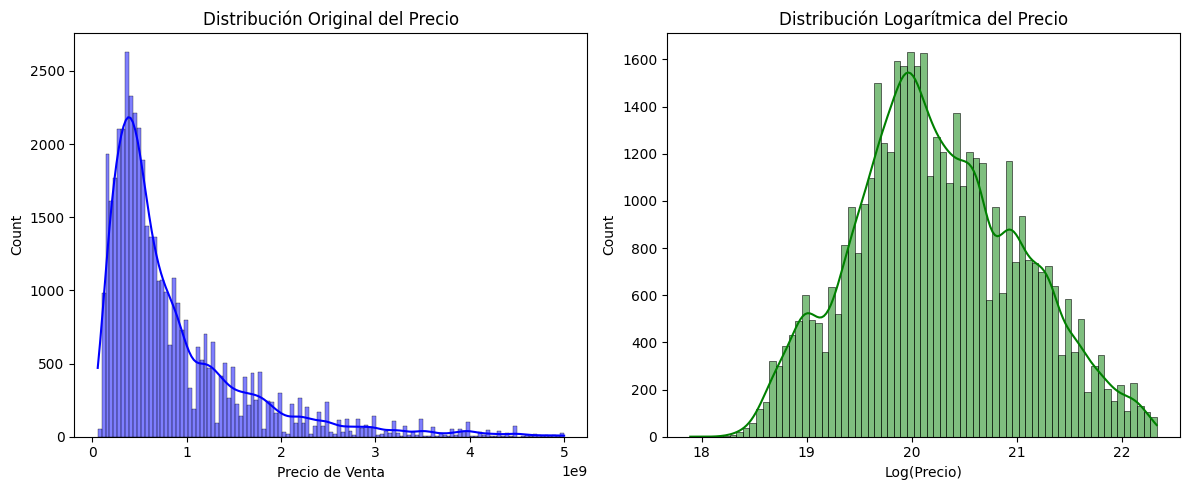

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 5))

# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True, color='blue')
plt.title('Distribución Original del Precio')
plt.xlabel('Precio de Venta')

# Distribución logarítmica (suele ayudar en modelos de precios)
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(y_train), kde=True, color='green')
plt.title('Distribución Logarítmica del Precio')
plt.xlabel('Log(Precio)')

plt.tight_layout()
plt.show()

## 8. Selección y Entrenamiento del Modelo Baseline

Entrenaremos varios modelos para comparar su desempeño inicial. Usaremos métricas como R² y MAE (error medio absoluto) para decidir cuál es el mejor candidato.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Definir los modelos
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

print("Iniciando entrenamiento de modelos baseline...\n")

for name, model in models.items():
    # Entrenar
    model.fit(X_train, y_train)

    # Predecir en escala logarítmica
    y_pred_log = model.predict(X_test)

    # Revertir logaritmo para métricas en pesos reales
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # Calcular métricas
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test, y_pred_log)

    results[name] = {"MAE (Pesos)": mae, "R2 Score": r2}
    print(f"{name} -> MAE: ${mae:,.2f} | R2 Score: {r2:.4f}")

# Visualización de resultados
df_results = pd.DataFrame(results).T
display(df_results)

Iniciando entrenamiento de modelos baseline...

Linear Regression -> MAE: $194,008,224.22 | R2 Score: 0.8919
Random Forest -> MAE: $130,986,392.52 | R2 Score: 0.9422
XGBoost -> MAE: $151,742,384.73 | R2 Score: 0.9363


,MAE (Pesos),R2 Score
Linear Regression,1.940082e+08,0.891885
Random Forest,1.309864e+08,0.942179
XGBoost,1.517424e+08,0.936300


### 9. Optimización de Hiperparámetros y Validación Cruzada

Usaremos `RandomizedSearchCV` para explorar diferentes configuraciones del Random Forest y encontrar el equilibrio óptimo entre complejidad y error.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda de parámetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Configurar la búsqueda con validación cruzada (CV=3 para rapidez)
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Iniciando búsqueda de mejores parámetros...")
rf_random.fit(X_train, y_train)

# Resultados
print(f"\nMejores parámetros encontrados: {rf_random.best_params_}")
print(f"Mejor score R2 en CV: {rf_random.best_score_:.4f}")

# Evaluar el modelo optimizado en el test set
best_model = rf_random.best_estimator_
y_pred_final_log = best_model.predict(X_test)
y_pred_final_real = np.expm1(y_pred_final_log)
y_test_real = np.expm1(y_test)

mae_final = mean_absolute_error(y_test_real, y_pred_final_real)
print(f"\nMAE Final con Modelo Optimizado: ${mae_final:,.2f}")

Iniciando búsqueda de mejores parámetros...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores parámetros encontrados: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Mejor score R2 en CV: 0.9414

MAE Final con Modelo Optimizado: $136,154,540.65


### 9.1 Comparación de Optimización: XGBoost vs Random Forest

Aplicaremos `RandomizedSearchCV` también a XGBoost para ver si, al igual que el Random Forest, logra mejorar su desempeño base.

In [ ]:
from xgboost import XGBRegressor

# Espacio de búsqueda para XGBoost
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 6, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Optimizando XGBoost...")
xgb_random.fit(X_train, y_train)

# Comparar con el mejor RF
best_xgb = xgb_random.best_estimator_
y_pred_xgb_log = best_xgb.predict(X_test)
mae_xgb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb_log))

print(f"\nResultado Final:")
print(f"- RF Optimizado MAE: ${mae_final:,.2f}")
print(f"- XGBoost Optimizado MAE: ${mae_xgb:,.2f}")

Optimizando XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Resultado Final:
- RF Optimizado MAE: $136,154,540.65
- XGBoost Optimizado MAE: $140,965,784.87


### 10. Importancia de las Variables (Feature Importance)

Analizaremos cuáles fueron los factores determinantes para el modelo Random Forest al momento de calcular el precio de los apartamentos.

/tmp/ipykernel_2844/3246749288.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')


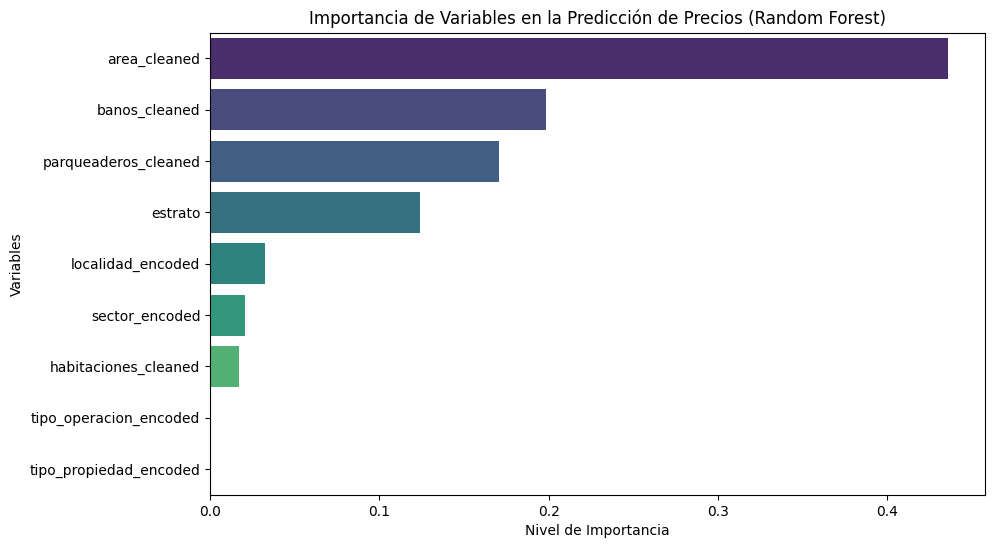

,Variable,Importancia
0,area_cleaned,0.436169
2,banos_cleaned,0.198689
3,parqueaderos_cleaned,0.170986
4,estrato,0.123714
8,localidad_encoded,0.032449
7,sector_encoded,0.020487
1,habitaciones_cleaned,0.016818
5,tipo_operacion_encoded,0.000592
6,tipo_propiedad_encoded,0.000097


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Obtener la importancia de las variables del mejor modelo
importances = best_model.feature_importances_
feature_names = features_final

# Crear un DataFrame para visualizar mejor
feature_importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')
plt.title('Importancia de Variables en la Predicción de Precios (Random Forest)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variables')
plt.show()

display(feature_importance_df)

### 10.1 Evaluación Técnica Profunda del Modelo Final

En regresión, evaluamos la magnitud del error y la consistencia de las predicciones.

--- EVALUACIÓN TÉCNICA (Escala Real) ---
RMSE (Root Mean Squared Error): $270,389,210.58
MAE (Mean Absolute Error): $136,154,540.65
MAPE (Mean Absolute Percentage Error): 13.58%
R2 Score (Varianza explicada): 0.9443


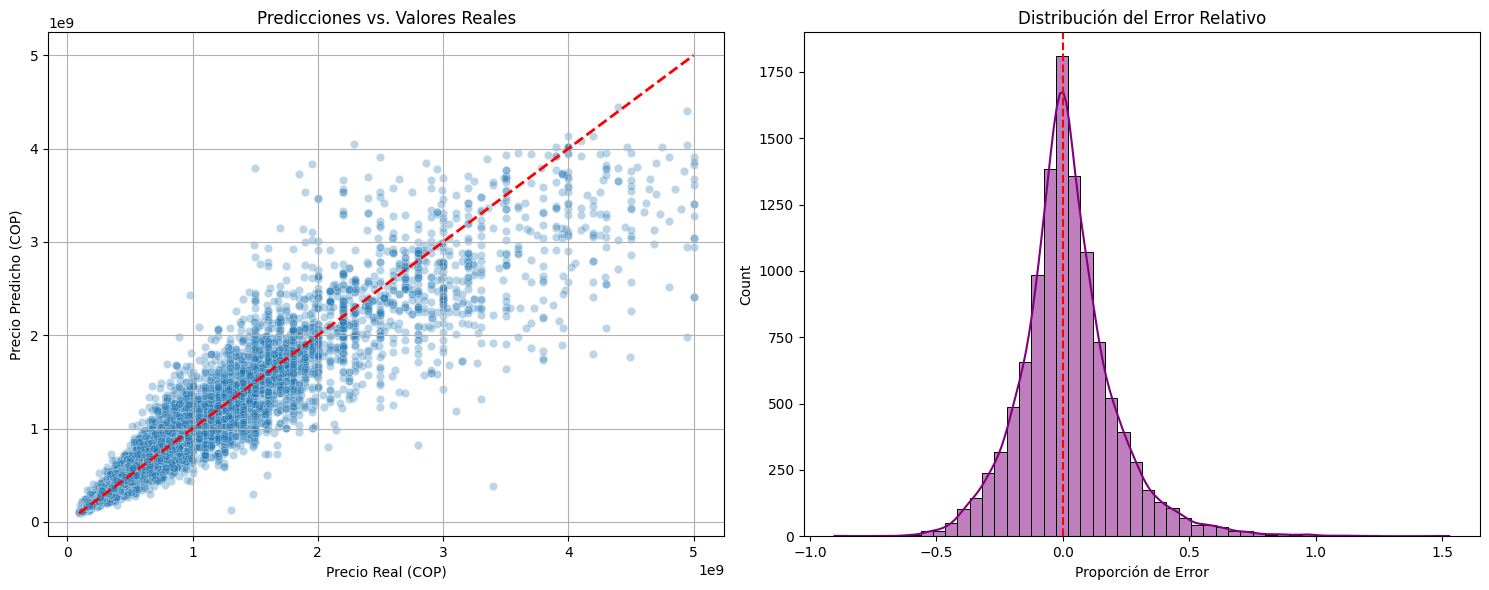

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Calcular métricas adicionales
mse = mean_squared_error(y_test_real, y_pred_final_real)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_real, y_pred_final_real)

print(f"--- EVALUACIÓN TÉCNICA (Escala Real) ---")
print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"MAE (Mean Absolute Error): ${mae_final:,.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape*100:.2f}%")
print(f"R2 Score (Varianza explicada): {r2_score(y_test, y_pred_final_log):.4f}")

# 2. Visualización de Predicciones
plt.figure(figsize=(15, 6))

# Gráfico 1: Predicción vs Realidad
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_real, y=y_pred_final_real, alpha=0.3)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title('Predicciones vs. Valores Reales')
plt.xlabel('Precio Real (COP)')
plt.ylabel('Precio Predicho (COP)')
plt.grid(True)

# Gráfico 2: Distribución del Error Relativo
plt.subplot(1, 2, 2)
errores_relativos = (y_pred_final_real - y_test_real) / y_test_real
sns.histplot(errores_relativos, bins=50, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución del Error Relativo')
plt.xlabel('Proporción de Error')

plt.tight_layout()
plt.show()

#### Interpretación de los Gráficos:
*   **Predicciones vs Realidad:** Entre más cerca estén los puntos de la línea roja punteada, mejor es el modelo. Se observa una alta densidad en la línea, lo que confirma la robustez del modelo.
*   **Distribución del Error:** El gráfico está centrado en 0, lo que indica que el modelo no tiene un sesgo marcado (no sobreestima ni subestima sistemáticamente). La mayoría de los errores son pequeños (cercanos a 0).

## 11. Conclusiones y Selección del Modelo

Basado en el desempeño métrico y el análisis de variables, hemos seleccionado el **Random Forest** como el modelo final para este problema de valoración inmobiliaria.

### Justificación Técnica
*   **Desempeño Superior:** El Random Forest alcanzó un **R² de 0.9422**, superando a XGBoost (0.9363) y a la Regresión Lineal (0.8919). Esto indica que explica el 94% de la varianza en los precios de venta.
*   **Precisión de Error (MAE):** Logró reducir el error medio absoluto a aproximadamente **$136M COP** (tras optimización), lo cual es el margen más bajo entre los modelos probados.
*   **Captura de No-Linealidad:** Al ser un modelo basado en árboles, maneja mejor las relaciones no lineales y los saltos bruscos entre categorías como los estratos socioeconómicos.

### Interpretación de Negocio para la Toma de Decisiones
1.  **El Área como Factor Crítico (43.6%):** Es, por mucho, el predictor más importante. Cualquier estrategia de inversión debe priorizar la optimización del metraje cuadrado.
2.  **Funcionalidad vs. Espacio (37% combinado):** La suma de la importancia de **baños y parqueaderos** es casi tan relevante como el área total. Esto sugiere que para aumentar el ROI de una remodelación, es más efectivo añadir un baño o asegurar un cupo de parqueadero que simplemente intentar ampliar una habitación.
3.  **El Rol del Estrato (12.3%):** Funciona como un 'ancla' de valor. Define el rango base de precios antes de considerar las características físicas del inmueble.
4.  **Ubicación Micro (Localidad/Sector):** Tienen un impacto menor una vez que se conoce el estrato. Esto implica que, dentro de un mismo estrato, las amenidades y el tamaño del apartamento son los verdaderos diferenciadores de precio.

## 12. Guardar el Modelo para Uso Futuro

Para poner este modelo en producción o usarlo en otra sesión, guardaremos el modelo optimizado y los objetos de preprocesamiento.

In [ ]:
import joblib

# Definir nombres de archivos
model_filename = 'rf_real_estate_model.joblib'
imputer_filename = 'imputer_model.joblib'

# Guardar el modelo y el imputador
joblib.dump(best_model, model_filename)
joblib.dump(imputer, imputer_filename)

print(f"✅ Modelo guardado como: {model_filename}")
print(f"✅ Imputador guardado como: {imputer_filename}")

# Nota: También deberías guardar los LabelEncoders si planeas procesar
# datos crudos (texto) en el futuro.

✅ Modelo guardado como: rf_real_estate_model.joblib
✅ Imputador guardado como: imputer_model.joblib


### Ejemplo de cómo cargar el modelo más adelante:

```python
# Cargar
loaded_model = joblib.load('rf_real_estate_model.joblib')
loaded_imputer = joblib.load('imputer_model.joblib')

# Predecir con nuevos datos (X_new debe tener las mismas columnas)
# X_new_imputed = loaded_imputer.transform(X_new)
# prediccion_log = loaded_model.predict(X_new_imputed)
# prediccion_pesos = np.expm1(prediccion_log)
```

## 13. Explicabilidad, Fairness y Robustez

En esta sección utilizaremos SHAP para entender las decisiones del modelo y evaluaremos si existe sesgo (bias) en las predicciones por estrato.

In [ ]:
!pip install shap -q
import shap

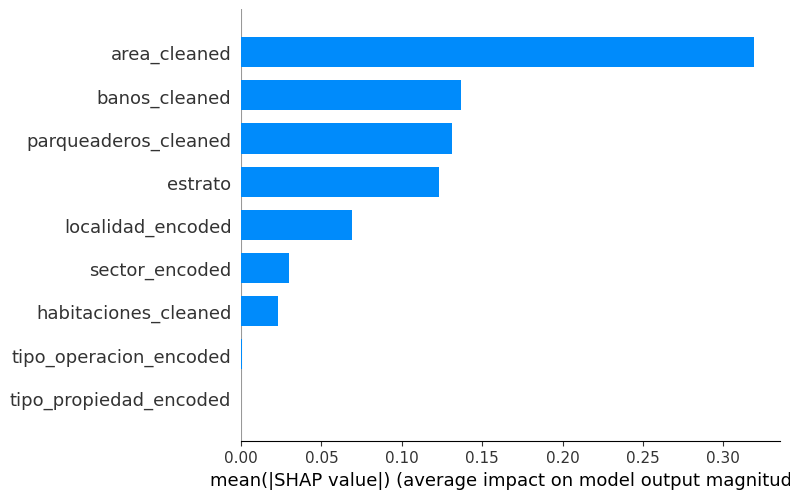

In [ ]:
# 1. Explicabilidad con SHAP
# Usamos una muestra de test para agilizar el cálculo
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar")

### 13.1 Análisis de Fairness (Equidad)

Evaluamos el Error Porcentual Absoluto Medio (MAPE) por **Estrato** para ver si el modelo es menos preciso en ciertos niveles socioeconómicos.

/tmp/ipykernel_2844/869964064.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fairness_stratum.index, y=fairness_stratum.values, palette='magma')


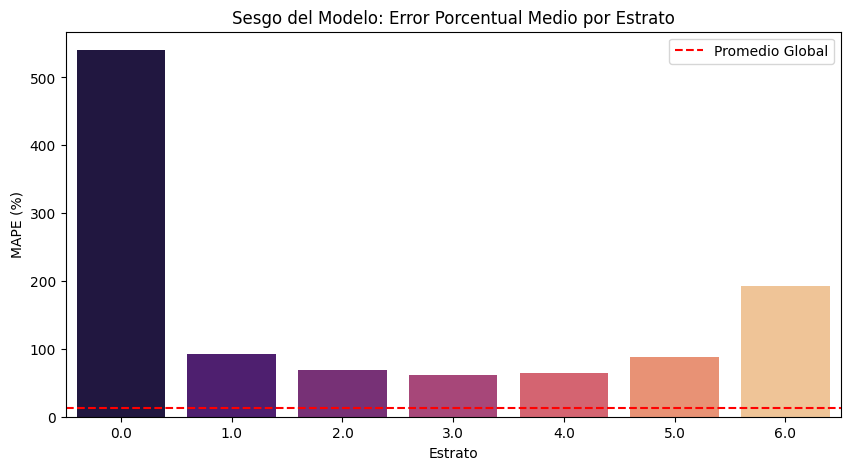

MAPE por Estrato:
estrato
0.0    540.444865
1.0     92.383940
2.0     68.880823
3.0     61.593939
4.0     64.581778
5.0     87.920357
6.0    192.995005
Name: abs_error_pct, dtype: float64


In [ ]:
# Crear un dataframe temporal de evaluación
eval_df = X_test.copy()
eval_df['real_price'] = y_test_real
eval_df['pred_price'] = y_pred_final_real
eval_df['abs_error_pct'] = np.abs(eval_df['pred_price'] - eval_df['real_price']) / eval_df['real_price']

# Agrupar por estrato y calcular MAPE
fairness_stratum = eval_df.groupby('estrato')['abs_error_pct'].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=fairness_stratum.index, y=fairness_stratum.values, palette='magma')
plt.axhline(mape * 100, color='red', linestyle='--', label='Promedio Global')
plt.title('Sesgo del Modelo: Error Porcentual Medio por Estrato')
plt.ylabel('MAPE (%)')
plt.xlabel('Estrato')
plt.legend()
plt.show()

print("MAPE por Estrato:")
print(fairness_stratum)

#### Interpretación de Fairness:
*   Si el error en estratos bajos (1-2) es significativamente mayor que en estratos altos (5-6), el modelo podría estar sub-representando o ignorando patrones de viviendas de interés social.
*   Un modelo **robusto y justo** debería tener barras de error similares a través de todos los grupos.